In [7]:
# Mounting G-Drive
from google.colab import drive
drive.mount('/content/drive')


# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Mounted at /content/drive
Device: cuda


In [8]:
# Paths for Dataset

data_dir = '/content/drive/My Drive/Lung Disease Dataset'
train_dir = f"{data_dir}/train"
val_dir = f"{data_dir}/val"
test_dir = f"{data_dir}/test"


In [9]:
# 4. Transforms and dataloaders
img_size = 224
batch_size = 32

train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

class_names = train_data.classes
num_classes = len(class_names)
print("Classes:", class_names)

Classes: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']


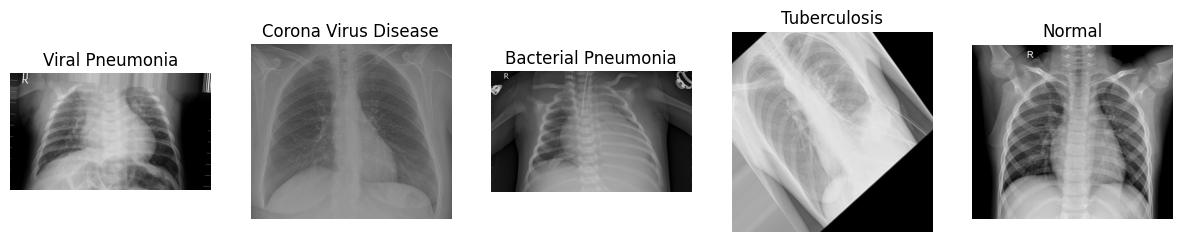

In [10]:
# 5. Visualize a sample image per class (optional, comment out if not needed)
import os
from PIL import Image

plt.figure(figsize=(15,6))
class_dirs = [os.path.join(train_dir, cls) for cls in os.listdir(train_dir)]
for idx, class_dir in enumerate(class_dirs):
    img_file = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, img_file)
    img = Image.open(img_path)
    plt.subplot(1, 5, idx+1)
    plt.imshow(img, cmap='gray')
    plt.title(os.path.basename(class_dir))
    plt.axis('off')
plt.show()

In [19]:
# 6. Model: DenseNet121 pretrained, classifier modified
model = models.densenet121(pretrained=True)
for param in model.parameters():
    param.requires_grad = False  # Freeze all layers

# Unfreeze last 2 dense block + classifier
for param in model.features.denseblock3.parameters():
    param.requires_grad = True
for param in model.features.denseblock4.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

# Now, optimizer should update only these parameters:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-6)

model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [20]:
# 7. Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# 8. Training loop
epochs = 20
best_acc = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels).item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_densenet_model.pth")

    scheduler.step()

Epoch 1/20 - Loss: 1.1898 - Val Acc: 0.7143
Epoch 2/20 - Loss: 0.7822 - Val Acc: 0.7842
Epoch 3/20 - Loss: 0.6734 - Val Acc: 0.7842
Epoch 4/20 - Loss: 0.6006 - Val Acc: 0.8080
Epoch 5/20 - Loss: 0.5582 - Val Acc: 0.8085
Epoch 6/20 - Loss: 0.5305 - Val Acc: 0.8150
Epoch 7/20 - Loss: 0.5354 - Val Acc: 0.8234
Epoch 8/20 - Loss: 0.5308 - Val Acc: 0.8135
Epoch 9/20 - Loss: 0.5247 - Val Acc: 0.8214
Epoch 10/20 - Loss: 0.5259 - Val Acc: 0.8259
Epoch 11/20 - Loss: 0.5215 - Val Acc: 0.8185
Epoch 12/20 - Loss: 0.5199 - Val Acc: 0.8259
Epoch 13/20 - Loss: 0.5178 - Val Acc: 0.8244
Epoch 14/20 - Loss: 0.5108 - Val Acc: 0.8185
Epoch 15/20 - Loss: 0.5259 - Val Acc: 0.8170
Epoch 16/20 - Loss: 0.5243 - Val Acc: 0.8214
Epoch 17/20 - Loss: 0.5259 - Val Acc: 0.8165
Epoch 18/20 - Loss: 0.5249 - Val Acc: 0.8175
Epoch 19/20 - Loss: 0.5235 - Val Acc: 0.8204
Epoch 20/20 - Loss: 0.5134 - Val Acc: 0.8026


In [21]:
# 9. Load best model & test evaluation
model.load_state_dict(torch.load("best_densenet_model.pth"))
model.eval()
test_correct = 0
test_preds = []
test_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        test_correct += torch.sum(preds == labels).item()
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
test_acc = test_correct / len(test_loader.dataset)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8207


Classification Report:
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.71      0.73      0.72       403
Corona Virus Disease       0.93      0.91      0.92       407
              Normal       0.80      0.94      0.86       404
        Tuberculosis       0.95      0.93      0.94       408
     Viral Pneumonia       0.71      0.60      0.65       403

            accuracy                           0.82      2025
           macro avg       0.82      0.82      0.82      2025
        weighted avg       0.82      0.82      0.82      2025



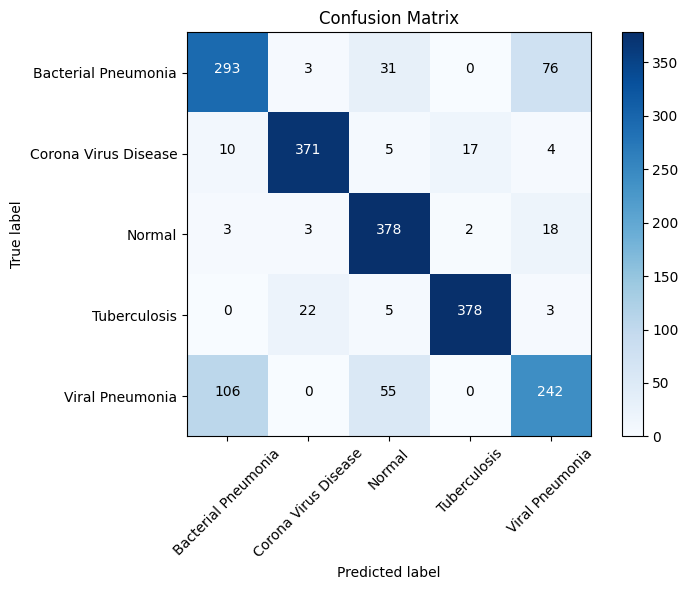

In [22]:
# 10. Classification report & confusion matrix
print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm = confusion_matrix(test_labels, test_preds)
plot_confusion_matrix(cm, class_names, title='Confusion Matrix')
plt.show()

In [ ]:
!cp best_densenet_model.pth /content/drive/MyDrive/


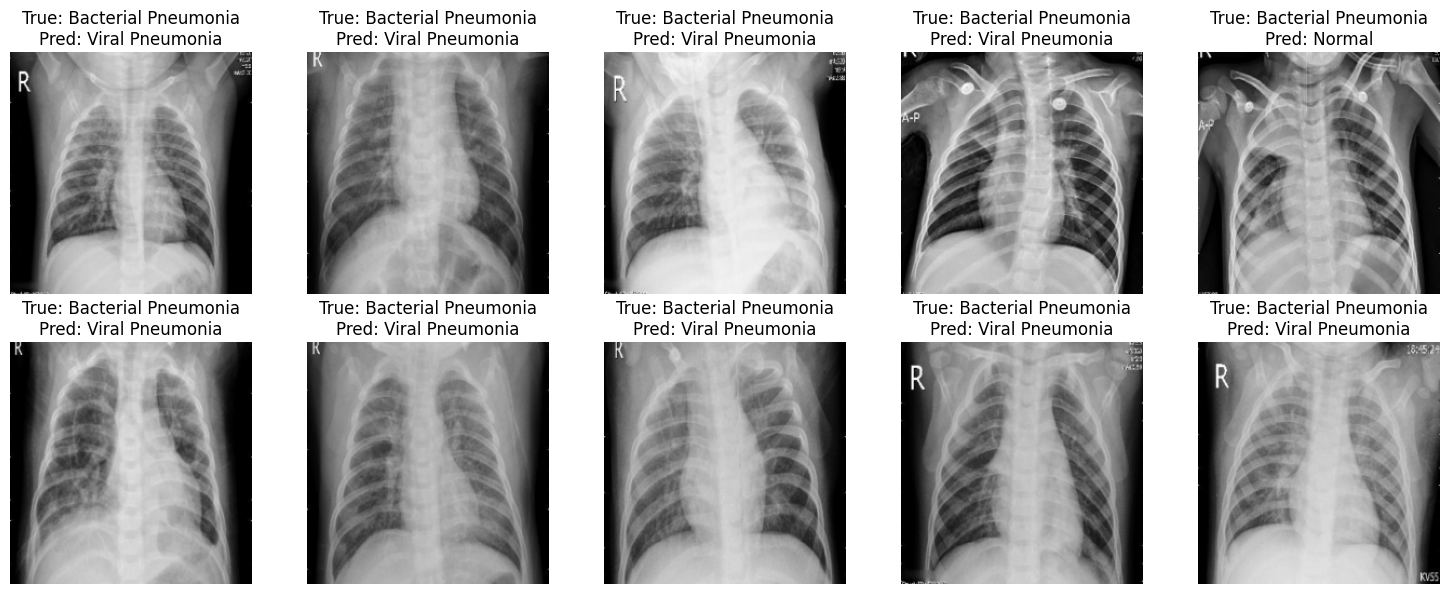

In [23]:
import matplotlib.pyplot as plt

def show_misclassified(test_loader, model, class_names, device, n=10):
    model.eval()
    misclassified = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified.append((images[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                if len(misclassified) >= n:
                    break
            if len(misclassified) >= n:
                break
    plt.figure(figsize=(15, 6))
    for i, (img, true, pred) in enumerate(misclassified):
        img = img.numpy().transpose((1,2,0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.subplot(2, n//2, i+1)
        plt.imshow(img)
        plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Usage:
show_misclassified(test_loader, model, class_names, device, n=10)
